In [1]:
import os
import numpy as np
import random
import cv2
from PIL import Image, ImageEnhance
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.utils import shuffle

In [2]:
#Data Collection
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Data Loading
import os
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

#load the train data
train_paths = [] #train images storation
train_labels = [] #read labels in trainData ie Glioma...etc

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)
train_paths, train_labels = shuffle(train_paths, train_labels)
print(Counter(train_labels))

#load the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)
print(Counter(test_labels))

Counter({'Glioma': 1400, 'Meningioma': 1400, 'Pituitary': 1400, 'Notumor': 1400})
Counter({'Pituitary': 400, 'Glioma': 400, 'Notumor': 400, 'Meningioma': 400})


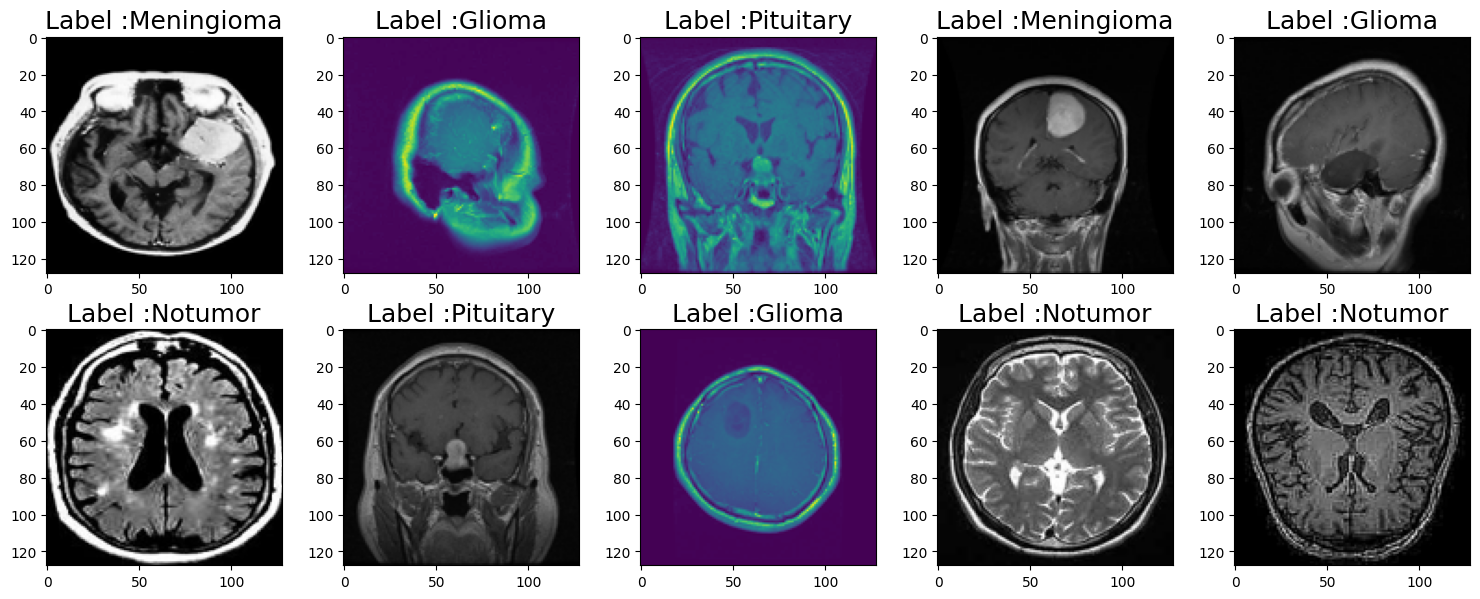

In [4]:
#Display
import random
import matplotlib.pyplot as plt

#select random index for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#create figure to display
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  #Display Imgs
  axes[i].imshow(img)
  axes[i].set_title(f"Label :{train_labels[idx]}", fontsize = 18)


plt.tight_layout()
plt.show()



In [5]:
#image Preprocessing
def augment_image(image):
    image = Image.fromarray(np.uint8(image)) #img to pillowLib format
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    #Convert Image to array for easier manipulation
    img_array = np.array(image, dtype=np.float32)
    img_array = preprocess_input(img_array)
    return img_array

#load images
def open_images(paths, image_size=(128, 128)):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE),color_mode="rgb")
        img = img_to_array(img)
        img = augment_image(img)
        img = cv2.GaussianBlur(img,(3,3),0)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = gray.astype('uint8')
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe.apply(gray)
        img = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        img = img.astype('float32')
        images.append(img)
    return np.array(images)

#convert labels name to integer
def encode_label(labels):
  unique_labels = sorted(os.listdir(train_dir))
  encoded_labels = [unique_labels.index(label) for label in labels]
  return encoded_labels

#data reads in batches i.e Generator
def datagen(paths, labels, batch_size=12):
    num_samples = len(paths)
    while True:
        indices = np.arange(num_samples)
        np.random.shuffle(indices)

        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i + batch_size]
            current_batch_paths = [paths[j] for j in batch_indices]
            current_batch_labels = [labels[j] for j in batch_indices]

            batch_images = open_images(current_batch_paths)
            batch_labels_encoded = encode_label(current_batch_labels)
            yield batch_images, np.array(batch_labels_encoded)


In [6]:
from functools import reduce
from tensorflow.keras.applications.efficientnet import EfficientNetB0
#Builidng Model
import cv2

IMAGE_SIZE = 128
base_model = EfficientNetB0(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet') #imagenet is predata

#freeze all layers of base model
for layer in base_model.layers[:-8]:
  layer.trainable = False
# Set last few layers
for layer in base_model.layers[-8:]:
  layer.trainable = True

#Build Final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add (Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))

#compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy']) # Corrected: 'sparse_categotical_accuracy' typo

#train the model
batch_size=32
steps = int(len(train_paths) / batch_size)
epochs= 15
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
#callbacks
checkpoint = ModelCheckpoint('model.keras', monitor='val_loss', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
#train
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size), steps_per_epoch=steps, epochs=epochs, callbacks=[checkpoint, early_stop, reduce_lr])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 0.9593 - sparse_categorical_accuracy: 0.6033

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


175/175 ━━━━━━━━━━━━━━━━━━━━ 1064s 6s/step - loss: 0.7375 - sparse_categorical_accuracy: 0.7214 - learning_rate: 1.0000e-04
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 157s 897ms/step - loss: 0.4398 - sparse_categorical_accuracy: 0.8370 - learning_rate: 1.0000e-04
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 155s 887ms/step - loss: 0.3558 - sparse_categorical_accuracy: 0.8670 - learning_rate: 1.0000e-04
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 157s 893ms/step - loss: 0.2969 - sparse_categorical_accuracy: 0.8904 - learning_rate: 1.0000e-04
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 155s 888ms/step - loss: 0.2641 - sparse_categorical_accuracy: 0.9052 - learning_rate: 1.0000e-04
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 158s 903ms/step - loss: 0.2304 - sparse_categorical_accuracy: 0.9137 - learning_rate: 1.0000e-04
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 156s 892ms/step - loss: 0.2154 - sparse_categorical_accuracy: 0.9212 - learning_rate: 1.0000e-04
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 156s 895ms/step - loss: 0.1945 - sparse_categorical_accuracy: 0.9286 - learning_rate: 1.0000e-04
Epoch 9/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 167s 953ms/s

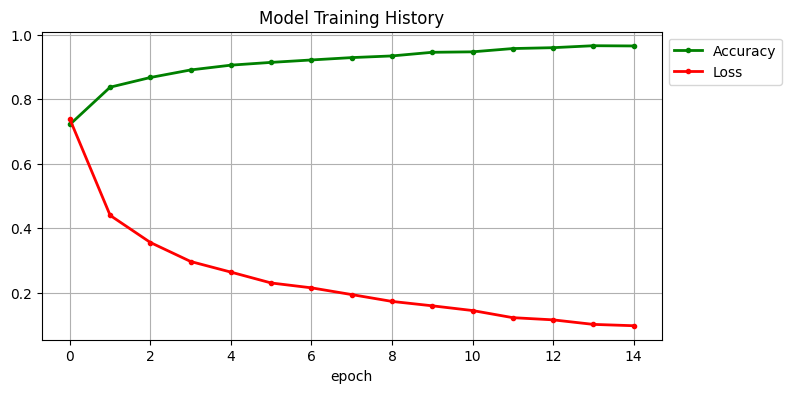

In [7]:
#Data Visulization GraphPlot
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [8]:
#Creating Report
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 754ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       400
           1       0.84      0.94      0.88       400
           2       0.95      1.00      0.97       400
           3       0.97      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



Confussion Matrix:
[[304  73  19   4]
 [ 15 376   2   7]
 [  0   0 400   0]
 [  3   1   0 396]]


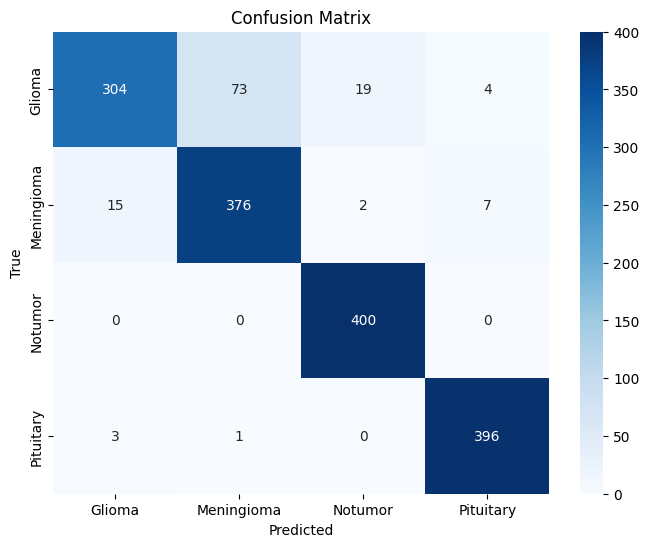

In [9]:
#creating ConfusionMatrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confussion Matrix:")
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [10]:
#save model
model.save('model.keras')

In [11]:
#load Model
from tensorflow.keras.models import load_model
model = load_model('model.keras')

In [12]:
#Print ImgWITHResult
from keras.preprocessing.image import load_img, img_to_array
class_labels = ['Glioma', 'Meningioma', 'Notumor','Pitutary']

def detect_and_display(image_path, model):
  try:
    img = load_img(image_path, target_size=(128, 128), color_mode="rgb")
    img_array = img_to_array(img)

    img_array = cv2.GaussianBlur(img_array,(3,3),0)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    gray = gray.astype('uint8')
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    img_array = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    img_array = img_array.astype('float32')
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence_score = np.max(prediction, axis=1)[0]

    if class_labels[predicted_class]== 'notumor':
      result = "No Tumor Detected"
    else:
      result = f"Tumor: {class_labels[predicted_class]} Detected with"

    # Display the image
    plt.imshow(gray, cmap='viridis')
    plt.axis('off')
    plt.title(f"{result} Confidence Score: {confidence_score * 100:.2f}%")
    plt.show()
  except Exception as e:
    print(f"Error processing image: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


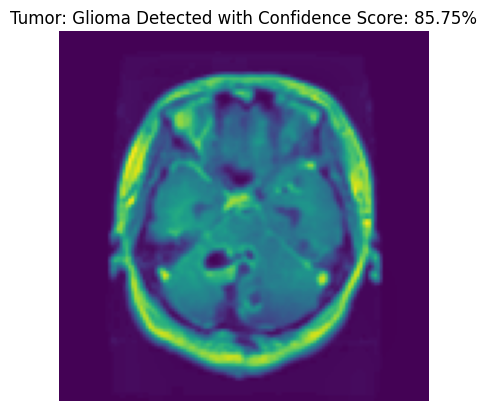

In [13]:
#Model Evaluation for testing
image_path = "/content/drive/MyDrive/MRI Images/Testing/Glioma/Te-gl_136.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


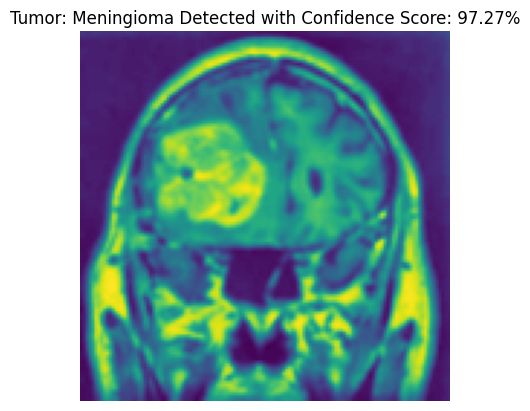

In [14]:
image_path = "/content/drive/MyDrive/MRI Images/Testing/Meningioma/Te-me_184.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


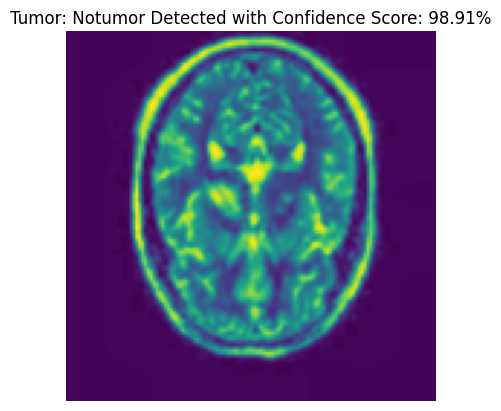

In [15]:
image_path = "/content/drive/MyDrive/MRI Images/Testing/Notumor/Te-no_15.jpg"
detect_and_display(image_path, model)